In [17]:
#importing libraries

import pandas as pd #dataframe
import seaborn as sns #plotting
import matplotlib.pyplot as plt #graph show

# ANOVA / MANOVA / Regression Libraries

from statsmodels.formula.api import ols #Anova model
import statsmodels.api as sm #Anova Summary
from statsmodels.stats.multicomp import pairwise_tukeyhsd #tukeyhsd hsd
import statsmodels.formula.api as smf #regression

In [7]:
df_ins = pd.read_csv(r"insurance.csv")

In [8]:
df_ins

,age,Gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [10]:
fit = ols("bmi ~ C(region)", data = df_ins).fit()
anova = sm.stats.anova_lm(fit, type = 1)
anova

,df,sum_sq,mean_sq,F,PR(>F)
C(region),3.0,4055.880631,1351.960210,39.495057,1.881839e-24
Residual,1334.0,45664.319755,34.231124,NaN,NaN


In [11]:
tukey1 = pairwise_tukeyhsd(df_ins["bmi"], groups=df_ins["region"])
tukey1._results_table

group1,group2,meandiff,p-adj,lower,upper,reject
northeast,northwest,0.0263,0.9999,-1.1552,1.2078,False
northeast,southeast,4.1825,0.0,3.033,5.332,True
northeast,southwest,1.4231,0.0107,0.2416,2.6046,True
northwest,southeast,4.1562,0.0,3.0077,5.3047,True
northwest,southwest,1.3968,0.0127,0.2162,2.5774,True
southeast,southwest,-2.7594,0.0,-3.9079,-1.6108,True


In [12]:
df_ins

,age,Gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


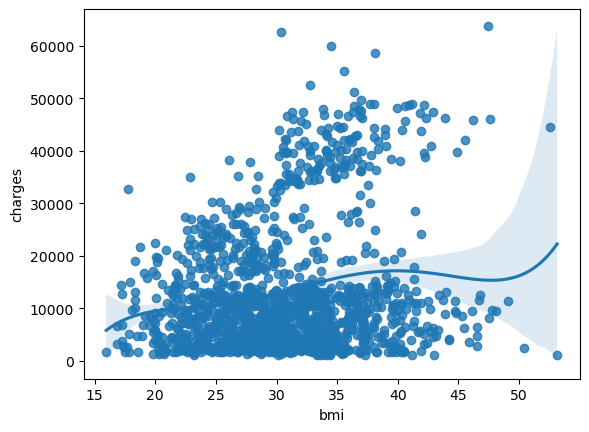

In [22]:
sns.regplot(data=df_ins, x = "bmi", y="charges", order=5)
plt.show()